# Gradient Artifact `t0` Detection and Synchronization Demo

Este notebook muestra como estimar `t0` directamente desde la morfologia de los artefactos de gradient en una senal EEG simultanea EEG-fMRI, sin usar trigger dedicado. Despues alinea la senal al inicio estimado y deja el resultado listo para limpiar GA con el pipeline existente.


In [14]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import mne
import numpy as np

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
SRC_ROOT = PROJECT_ROOT / "src"
if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

from functions.aas_ga import run_aas_pipeline
from functions.gradient_sync import detect_gradient_artifact_start
from functions.load_fmri_metadata import load_fmri_metadata


In [28]:
EEG_ROOT = PROJECT_ROOT / "data" / "raw" / "Dataset1" / "Simultaneous_EEG_fMRI" / "BIDS_dataset_EEG"
FMRI_ROOT = PROJECT_ROOT / "data" / "raw" / "Dataset1" / "Simultaneous_EEG_fMRI" / "BIDS_dataset_MRI"

SUBJECT = "sub-007"
EEG_TASK = "fmrirestingec"
FMRI_TASK = "rest"

CALIBRATION_SECONDS = 600.0
THRESHOLD_SIGMA = 3.0
MIN_CHANNELS_FRACTION = 0.05
REFRACTORY_MS = 10.0
CLUSTER_TOLERANCE_MS = 12.0
REFERENCE_CHANNEL = 0
MAX_CHANNELS_TO_PLOT = 3
PLOT_WINDOW_SECONDS = 4.0

def get_eeg_set_path(subject: str, task: str = EEG_TASK, eeg_root: Path = EEG_ROOT) -> Path:
    eeg_path = eeg_root / subject / "eeg" / f"{subject}_task-{task}_eeg.set"
    if not eeg_path.exists():
        raise FileNotFoundError(f"EEG file not found: {eeg_path}")
    return eeg_path


def get_fmri_nifti_path(subject: str, task: str = FMRI_TASK, fmri_root: Path = FMRI_ROOT) -> Path:
    fmri_path = fmri_root / subject / "ses-001" / "func" / f"{subject}_ses-001_task-{task}_bold.nii.gz"
    if not fmri_path.exists():
        raise FileNotFoundError(f"fMRI file not found: {fmri_path}")
    return fmri_path


def load_raw_eeg(eeg_path: Path) -> mne.io.BaseRaw:
    return mne.io.read_raw_eeglab(eeg_path, preload=True, verbose="ERROR")


def select_analysis_channels(raw: mne.io.BaseRaw) -> tuple[list[int], list[str]]:
    excluded_tokens = ("ECG", "EKG", "VREF", "TRIG", "STI", "MISC", "RESP", "EOG", "EMG", "AUX")
    picks: list[int] = []
    names: list[str] = []
    for index, channel_name in enumerate(raw.ch_names):
        upper_name = channel_name.upper()
        if any(token in upper_name for token in excluded_tokens):
            continue
        picks.append(index)
        names.append(channel_name)
    if not picks:
        picks = list(range(len(raw.ch_names)))
        names = list(raw.ch_names)
    return picks, names


## Load data

El ejemplo usa un sujeto real del dataset, pero puedes cambiar `SUBJECT` y `EEG_TASK` para probar otra sesion. El dataset no expone un trigger dedicado en EEG, asi que el inicio de la secuencia fMRI se estima por la morfologia de los artefactos.


In [29]:
eeg_path = get_eeg_set_path(SUBJECT)
fmri_path = get_fmri_nifti_path(SUBJECT)

raw = load_raw_eeg(eeg_path)
fmri_info = load_fmri_metadata(fmri_path)

analysis_picks, analysis_names = select_analysis_channels(raw)
eeg_signal = raw.get_data(picks=analysis_picks)
fs = float(raw.info["sfreq"])

print(f"Subject: {SUBJECT}")
print(f"EEG task: {EEG_TASK}")
print(f"EEG path: {eeg_path}")
print(f"fMRI path: {fmri_path}")
print(f"EEG shape: {eeg_signal.shape}")
print(f"Sampling frequency: {fs} Hz")
print(f"Selected channels: {len(analysis_picks)} / {len(raw.ch_names)}")
print(f"fMRI TR: {fmri_info['TR_s']} s")
print(f"fMRI TE: {fmri_info['TE_s']} s")
print(f"fMRI slices: {fmri_info['n_slices']}")
print(f"fMRI matrix XY: {fmri_info['matrix_xy']}")
print("Dynamic range note: the dataset metadata available here does not expose the EEG hardware input range, so ±65.5 mV cannot be confirmed from the files alone.")


Subject: sub-007
EEG task: fmrirestingec
EEG path: C:\Users\pedro\Documents\DOCTORADO_Pedro\Code\phD_Repository\data\raw\Dataset1\Simultaneous_EEG_fMRI\BIDS_dataset_EEG\sub-007\eeg\sub-007_task-fmrirestingec_eeg.set
fMRI path: C:\Users\pedro\Documents\DOCTORADO_Pedro\Code\phD_Repository\data\raw\Dataset1\Simultaneous_EEG_fMRI\BIDS_dataset_MRI\sub-007\ses-001\func\sub-007_ses-001_task-rest_bold.nii.gz
EEG shape: (32, 628889)
Sampling frequency: 1000.0 Hz
Selected channels: 32 / 33
fMRI TR: 2 s
fMRI TE: 0.04 s
fMRI slices: 35
fMRI matrix XY: (64, 64)
Dynamic range note: the dataset metadata available here does not expose the EEG hardware input range, so ±65.5 mV cannot be confirmed from the files alone.


## Estimate `t0`

The detector uses a calibration window to estimate a robust threshold, applies peak thinning, merges detections across channels, and validates the periodicity against the expected `TR / n_slices` spacing.


In [30]:
detection = detect_gradient_artifact_start(
    eeg_signal,
    fs=fs,
    tr_sec=float(fmri_info["TR_s"]),
    n_slices=int(fmri_info["n_slices"]),
    channel_names=analysis_names,
    calibration_seconds=CALIBRATION_SECONDS,
    threshold_sigma=THRESHOLD_SIGMA,
    min_channels_fraction=MIN_CHANNELS_FRACTION,
    refractory_ms=REFRACTORY_MS,
    cluster_tolerance_ms=CLUSTER_TOLERANCE_MS,
    min_cycle_peaks=3,
)

print(f"t0 sample: {detection.t0_sample}")
print(f"t0 time: {detection.t0_sec:.6f} s")
print(f"t_f sample: {detection.t_f_sample}")
print(f"t_f time: {detection.t_f_sec:.6f} s")
print(f"Threshold: {detection.threshold:.6f}")
print(f"Calibration seconds used: {detection.calibration_seconds:.1f}")
print(f"Slice period: {detection.slice_period_sec:.6f} s")
print(f"Consensus peaks: {detection.consensus_peaks.size}")
print(f"Min consensus votes: {int(detection.consensus_votes.min())}")


t0 sample: 6030
t0 time: 6.030000 s
t_f sample: 626027
t_f time: 626.027000 s
Threshold: 0.000502
Calibration seconds used: 600.0
Slice period: 0.057143 s
Consensus peaks: 10854
Min consensus votes: 2


## Visual check around `t0`

This plot shows a short window around the estimated onset. The red line marks the first detected RF pulse that defines `t0`.


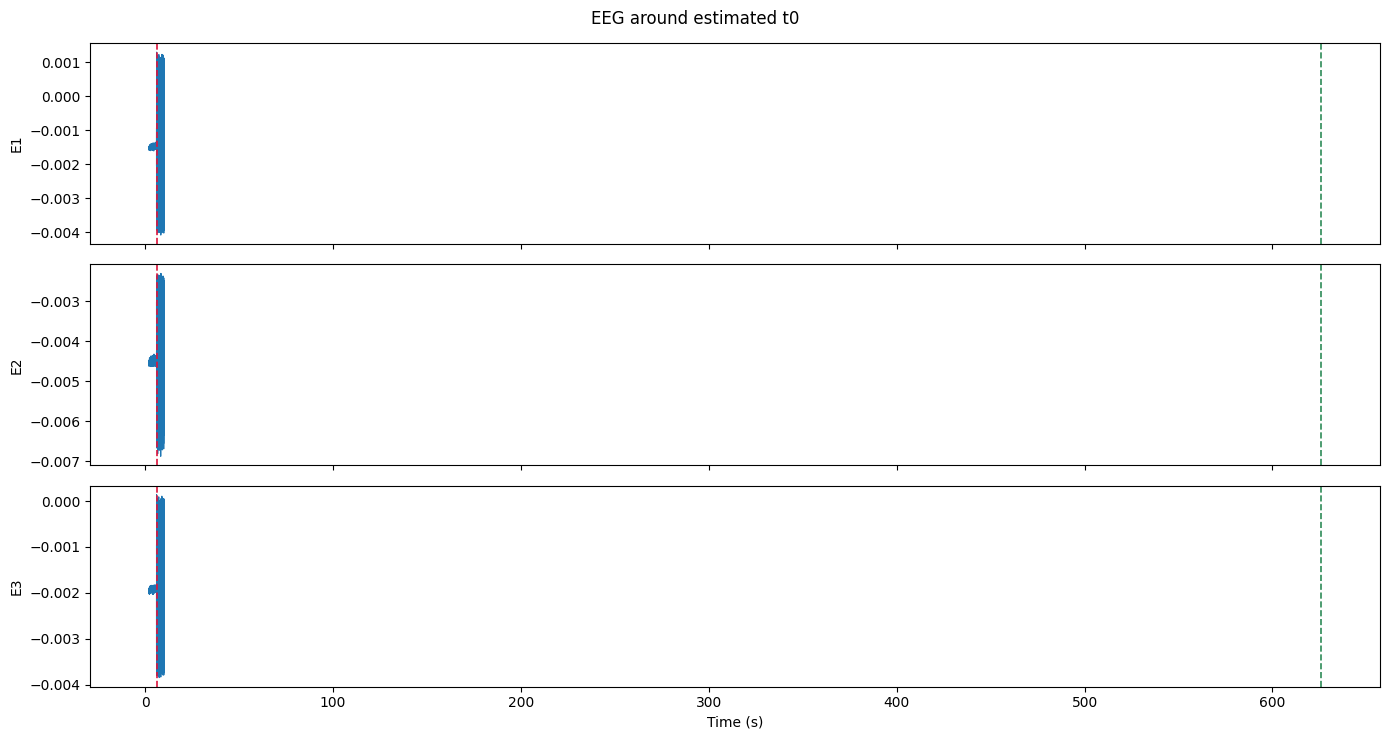

In [31]:
window_samples = int(round(PLOT_WINDOW_SECONDS * fs))
start = max(0, detection.t0_sample - window_samples)
stop = min(eeg_signal.shape[1], detection.t0_sample + window_samples)
time_axis = np.arange(start, stop) / fs

n_plot = min(MAX_CHANNELS_TO_PLOT, eeg_signal.shape[0])
fig, axes = plt.subplots(n_plot, 1, figsize=(14, 2.5 * n_plot), sharex=True)
if n_plot == 1:
    axes = [axes]

for axis, channel_index in zip(axes, range(n_plot), strict=False):
    axis.plot(time_axis, eeg_signal[channel_index, start:stop], linewidth=0.8)
    axis.axvline(detection.t0_sec, color="crimson", linestyle="--", linewidth=1.2)
    axis.axvline(detection.t_f_sec, color="seagreen", linestyle="--", linewidth=1.2)
    axis.set_ylabel(analysis_names[channel_index])

axes[-1].set_xlabel("Time (s)")
fig.suptitle("EEG around estimated t0")
fig.tight_layout()


## Synchronize and prepare for GA cleaning

The simplest synchronization is to re-reference time so that the first detected RF pulse becomes `t = 0`. The same `t0` and `t_f` can then be used to crop the fMRI interval and pass the onset as the `offset` for the existing trigger-free AAS pipeline.


In [32]:
aligned_signal = eeg_signal[:, detection.t0_sample:detection.t_f_sample]
aligned_time = np.arange(aligned_signal.shape[1]) / fs
print(f"Aligned fMRI interval: {detection.t0_sec:.6f} s -> {detection.t_f_sec:.6f} s")

aas_result = run_aas_pipeline(
    aligned_signal,
    TR=float(fmri_info["TR_s"]),
    fs=fs,
    reference_channel=REFERENCE_CHANNEL,
    offset=0,
    window_size=21,
)

cleaned_signal = aas_result["cleaned_signal"]
print(f"Aligned signal shape: {aligned_signal.shape}")
print(f"Cleaned signal shape: {cleaned_signal.shape}")
print(f"AAS offset used: {aas_result['offset']}")
print(f"TR samples: {aas_result['T_samples']}")
print(f"First segment lag estimates: {aas_result['lags'][:10]}")


Aligned fMRI interval: 6.030000 s -> 626.027000 s
Aligned signal shape: (32, 619997)
Cleaned signal shape: (32, 619997)
AAS offset used: 0
TR samples: 2000
First segment lag estimates: [169 169 169 169 169 169 169 169 169 169]


## MNE visualization

The same aligned interval can be opened with the MNE browser, matching the style used in the other GA notebooks.


In [33]:
mne.viz.set_browser_backend("qt")

mne_info = mne.create_info(ch_names=analysis_names, sfreq=fs, ch_types=["eeg"] * len(analysis_names))
aligned_raw_mne = mne.io.RawArray(aligned_signal, mne_info.copy(), verbose="ERROR")
cleaned_raw_mne = mne.io.RawArray(cleaned_signal, mne_info.copy(), verbose="ERROR")

print("Aligned EEG window in MNE browser")
aligned_raw_mne.plot(n_channels=min(20, len(analysis_names)), duration=10, show_scrollbars=True, block=True)

print("Cleaned EEG window in MNE browser")
cleaned_raw_mne.plot(n_channels=min(20, len(analysis_names)), duration=10, show_scrollbars=True, block=True)


Aligned EEG window in MNE browser
Channels marked as bad:
none
Cleaned EEG window in MNE browser
Channels marked as bad:
none
